# ⚡ Stima Performance – PdC + FV + Accumulo
### Notebook interattivo con input guidati

Esegui le celle in ordine. Ogni sezione ti chiederà i dati necessari tramite widget interattivi.

---

## 0 · Setup – Import e installazione dipendenze

In [1]:
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["demandlib", "holidays", "ipywidgets", "requests"]:
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installazione {pkg}...")
        pip_install(pkg)

import warnings
import re
import io
import json
from pathlib import Path
from urllib.parse import quote
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import holidays
import requests
from demandlib import bdew

warnings.simplefilter("always", UserWarning)
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True})

# Stato globale del notebook
stato = {}

# Valori guida volutamente semplici: servono per una stima preliminare, non per sostituire una Legge 10.
# Gli ordini di grandezza sono coerenti con range pratici ricorrenti: edifici efficienti ~50 W/m² o meno,
# edifici medi/scarsi ~80–100 W/m², con correzione cautelativa per zona climatica.
W_M2_PROGETTO = {
    "nuova":   {"A/B": 25, "C": 30, "D": 35, "E": 40, "F": 45},
    "vecchia": {"A/B": 50, "C": 65, "D": 80, "E": 95, "F": 110},
}
T_MANDATA_TERMINALI = {
    "radiatori": 65.0,
    "fancoil": 45.0,
    "pavimento_radiante": 35.0,
}


def intestazione(testo, colore="#1a5276"):
    display(HTML(f'<div style="background:{colore};color:white;padding:10px 16px;border-radius:6px;font-size:15px;font-weight:bold;margin:10px 0">{testo}</div>'))

def ok(testo):
    display(HTML(f'<div style="background:#d5f5e3;color:#1e8449;padding:8px 14px;border-radius:5px;margin:4px 0">✅ {testo}</div>'))

def warn(testo):
    display(HTML(f'<div style="background:#fef9e7;color:#b7770d;padding:8px 14px;border-radius:5px;margin:4px 0">⚠️ {testo}</div>'))

def errore(testo):
    display(HTML(f'<div style="background:#fadbd8;color:#922b21;padding:8px 14px;border-radius:5px;margin:4px 0">⛔ {testo}</div>'))

def stima_potenza_progetto_kw(area_m2, zona_climatica, tipo_edificio):
    w_m2 = W_M2_PROGETTO[tipo_edificio][zona_climatica]
    return area_m2 * w_m2 / 1000.0, w_m2

def geocodifica_comune(comune, provincia=None):
    """Restituisce lat/lon da Nominatim, provando Comune+Provincia e poi Comune."""
    comune = str(comune).strip()
    provincia = str(provincia).strip() if provincia else ""
    if not comune:
        raise ValueError("Inserisci il nome del comune.")

    tentativi = []
    if provincia:
        tentativi.append(f"{comune}, {provincia}, Italia")
    tentativi.append(f"{comune}, Italia")
    tentativi.append(comune)

    headers = {"User-Agent": "stima-performance-pdc-fv-notebook/1.0"}
    for query in tentativi:
        url = "https://nominatim.openstreetmap.org/search"
        params = {"q": query, "format": "json", "limit": 1, "countrycodes": "it"}
        r = requests.get(url, params=params, headers=headers, timeout=20)
        r.raise_for_status()
        data = r.json()
        if data:
            return float(data[0]["lat"]), float(data[0]["lon"]), data[0].get("display_name", query)

    raise ValueError(f"Comune non trovato: {comune}, {provincia}, Italia")

def scarica_tmy_pvgis(lat, lon):
    """Scarica il TMY PVGIS 5.3 in JSON e restituisce un DataFrame normalizzato."""
    url = "https://re.jrc.ec.europa.eu/api/v5_3/tmy"
    params = {"lat": lat, "lon": lon, "outputformat": "json"}
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()
    rows = js.get("outputs", {}).get("tmy_hourly")
    if rows is None:
        raise ValueError("Risposta PVGIS inattesa: campo outputs.tmy_hourly assente.")
    return pd.DataFrame(rows)

def normalizza_tmy(df_raw):
    """Uniforma i nomi colonna PVGIS e crea timestamp, mese, day-of-year e ora."""
    df = df_raw.copy()
    if "time(UTC)" not in df.columns:
        # PVGIS JSON usa spesso 'time(UTC)'; alcuni export possono avere 'time'.
        possibili = [c for c in df.columns if c.lower().startswith("time")]
        if possibili:
            df = df.rename(columns={possibili[0]: "time(UTC)"})
    rename = {"T2m": "T_ext_C", "G(h)": "GHI", "Gd(h)": "DHI"}
    df = df.rename(columns=rename)
    colonne = ["time(UTC)", "T_ext_C", "GHI", "DHI"]
    manc = [c for c in colonne if c not in df.columns]
    if manc:
        raise ValueError(f"Colonne TMY mancanti: {manc}")
    df = df[colonne].copy()
    df["timestamp_old"] = pd.to_datetime(df["time(UTC)"], format="%Y%m%d:%H%M", errors="coerce")
    if df["timestamp_old"].isna().all():
        df["timestamp_old"] = pd.to_datetime(df["time(UTC)"], errors="coerce")
    df = df.dropna(subset=["timestamp_old"])
    for c in ["T_ext_C", "GHI", "DHI"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["T_ext_C"])
    df["GHI"] = df["GHI"].fillna(0)
    df["DHI"] = df["DHI"].fillna(0)
    df["doy"] = df["timestamp_old"].dt.dayofyear
    df["hour"] = df["timestamp_old"].dt.hour
    df["timestamp"] = (pd.to_datetime("2025-01-01")
                       + pd.to_timedelta(df["doy"] - 1, unit="D")
                       + pd.to_timedelta(df["hour"], unit="h"))
    df["mese"] = df["timestamp"].dt.month
    return df.reset_index(drop=True)


def leggi_tmy_csv_pvgis_locale(path_tmy):
    """
    Legge un file CSV TMY PVGIS locale anche se contiene righe iniziali di metadati.
    Cerca automaticamente la riga di intestazione dei dati orari.
    """
    with open(path_tmy, "r", encoding="utf-8", errors="ignore") as f:
        righe = f.readlines()

    idx_header = None
    sep = ","

    for i, riga in enumerate(righe):
        r = riga.strip()
        if not r:
            continue

        sep_test = ";" if ";" in r and r.count(";") > r.count(",") else ","
        campi = [c.strip().replace('"', "") for c in r.split(sep_test)]

        cond_time = len(campi) > 1 and campi[0].lower().startswith("time")
        cond_pvgis = "T2m" in campi and any(c in campi for c in ["G(h)", "Gb(n)", "Gd(h)", "RH"])

        if cond_time or cond_pvgis:
            idx_header = i
            sep = sep_test
            break

    if idx_header is None:
        # Fallback: utile se il CSV è già pulito.
        return pd.read_csv(path_tmy)

    df = pd.read_csv(
        path_tmy,
        skiprows=idx_header,
        sep=sep,
        engine="python"
    )

    df.columns = [str(c).strip().replace('"', "") for c in df.columns]

    # Rimuove eventuali righe finali non orarie/metadati.
    if "T2m" in df.columns:
        df = df[pd.to_numeric(df["T2m"], errors="coerce").notna()].copy()

    return df

print("✅ Setup completato.")


✅ Setup completato.


---
## 1 · Taglie impianto e dati PdC

In [3]:
intestazione("🔧 STEP 1 – Taglie impianto")

w_fvt    = widgets.FloatText(value=6.0,  description="FVT [kWp]:",  style={"description_width":"150px"}, layout=widgets.Layout(width="320px"))
w_bess   = widgets.FloatText(value=10.2, description="Batterie [kWh]:", style={"description_width":"150px"}, layout=widgets.Layout(width="320px"))
w_pdc_kw = widgets.FloatText(value=11.3, description="PdC pot. term. [kW]:", style={"description_width":"150px"}, layout=widgets.Layout(width="320px"))
w_scop   = widgets.FloatText(value=3.50, description="SCOP PdC (Default 3.5):",   style={"description_width":"190px"}, layout=widgets.Layout(width="370px"))

display(widgets.VBox([
    widgets.HTML("<b>Inserisci le taglie dei componenti:</b>"),
    w_fvt, w_bess, w_pdc_kw, w_scop,
    widgets.HTML("<i>L'ACS si imposta nello STEP 4 scegliendo il generatore dedicato.</i>")
]))

btn1 = widgets.Button(description="✔ Conferma taglie", button_style="success", layout=widgets.Layout(width="220px", margin="10px 0"))
out1 = widgets.Output()

def salva_taglie(_):
    with out1:
        clear_output()
        stato["taglia_PV"]   = w_fvt.value
        stato["taglia_BESS"] = w_bess.value
        stato["P_pdc_kW"]    = w_pdc_kw.value
        stato["SCOP"]        = w_scop.value
        ok(f"FVT={stato['taglia_PV']} kWp | Batterie={stato['taglia_BESS']} kWh | PdC={stato['P_pdc_kW']} kW | SCOP={stato['SCOP']}")

btn1.on_click(salva_taglie)
display(btn1, out1)


Button(button_style='success', description='✔ Conferma taglie', layout=Layout(margin='10px 0', width='220px'),…

Output()

---
## 2 · Dati edificio e clima

In [4]:
intestazione("🏠 STEP 2 – Edificio, clima e tariffe")

import os
import unicodedata


def nome_file_tmy_provincia(provincia):
    """
    Trasforma il nome provincia nel formato usato per i file TMY.
    Es. Pisa -> PisaTMY.csv
        La Spezia -> LaSpeziaTMY.csv
        Reggio Emilia -> ReggioEmiliaTMY.csv
        Valle d'Aosta -> ValledAostaTMY.csv
    """
    p = str(provincia).strip()
    p = unicodedata.normalize("NFKD", p).encode("ascii", "ignore").decode("ascii")
    p = p.replace("'", "").replace("’", "")
    p = "".join(ch for ch in p.title() if ch.isalnum())
    return f"{p}TMY.csv"


w_comune = widgets.Text(value="Larciano", description="Comune:", style={"description_width":"220px"}, layout=widgets.Layout(width="460px"))
w_provincia = widgets.Text(value="Pistoia", description="Provincia:", style={"description_width":"220px"}, layout=widgets.Layout(width="460px"))

w_Q_mode = widgets.RadioButtons(
    options=[("Inserisco io la potenza di progetto", "manuale"), ("Stima rapida da superficie/zona/età edificio", "stima")],
    value="manuale", description="Potenza progetto:", style={"description_width":"180px"}
)
w_Q      = widgets.FloatText(value=12.0, description="Potenza progetto [kW]:", style={"description_width":"220px"}, layout=widgets.Layout(width="400px"))
w_area   = widgets.FloatText(value=140.0, description="Superficie riscaldata [m²]:", style={"description_width":"220px"}, layout=widgets.Layout(width="400px"))
w_zona   = widgets.Dropdown(options=["A/B", "C", "D", "E", "F"], value="D", description="Zona climatica:", style={"description_width":"220px"}, layout=widgets.Layout(width="400px"))
w_tipo_ed = widgets.RadioButtons(options=[("Casa nuova / ben isolata", "nuova"), ("Casa esistente / vecchia", "vecchia")], value="vecchia", description="Tipo edificio:", style={"description_width":"180px"})
w_Text   = widgets.FloatText(value=-1.0, description="T esterna progetto [°C] (Default -1):", style={"description_width":"280px"}, layout=widgets.Layout(width="470px"))
w_terminali = widgets.RadioButtons(
    options=[("Radiatori → 65 °C", "radiatori"), ("Fancoil → 45 °C", "fancoil"), ("Pavimento radiante → 35 °C", "pavimento_radiante")],
    value="pavimento_radiante", description="Terminali:", style={"description_width":"120px"}
)
w_tilt_fv = widgets.FloatText(
    value=30.0,
    description="Inclinazione FV [°] (Default 30):",
    style={"description_width":"280px"},
    layout=widgets.Layout(width="470px")
)

w_cel    = widgets.FloatText(value=0.30, description="Costo elettricità [€/kWh] (Default 0.30):", style={"description_width":"310px"}, layout=widgets.Layout(width="540px"))
w_pmg    = widgets.FloatText(value=0.045, description="Prezzo vendita in rete energia FV [€/kWh] (Default 0.045):", style={"description_width":"400px"}, layout=widgets.Layout(width="650px"))
w_cgas   = widgets.FloatText(value=0.10, description="Costo gas [€/kWh] (Default 0.10):", style={"description_width":"310px"}, layout=widgets.Layout(width="540px"))

area_potenza = widgets.Output()

def aggiorna_potenza(change=None):
    with area_potenza:
        clear_output()
        if w_Q_mode.value == "manuale":
            display(w_Q)
        else:
            display(widgets.HTML("<i>Stima preliminare con W/m² indicativi: nuova 25–45 W/m², vecchia 50–110 W/m² secondo zona.</i>"))
            display(w_area, w_zona, w_tipo_ed)

w_Q_mode.observe(aggiorna_potenza, names="value")

display(widgets.VBox([
    widgets.HTML("<b>Parametri edificio:</b>"),
    w_Q_mode, area_potenza, w_Text, w_terminali,
    widgets.HTML("<b>Clima e TMY:</b>"),
    widgets.HTML("<i>Il TMY viene letto automaticamente dalla cartella <code>TMY_PVGIS</code> in base alla provincia. Il comune serve solo per la localizzazione climatica.</i>"),
    w_comune, w_provincia,
    widgets.HTML("<b>Parametri Fotovoltaico:</b>"),
    w_tilt_fv,
    widgets.HTML("<b>Tariffe energetiche:</b>"),
    w_cel, w_pmg, w_cgas,
]))
aggiorna_potenza()

btn2 = widgets.Button(description="✔ Conferma", button_style="success", layout=widgets.Layout(width="220px", margin="10px 0"))
out2 = widgets.Output()

def salva_edificio(_):
    with out2:
        clear_output()
        stato["comune"] = w_comune.value.strip()
        stato["provincia"] = w_provincia.value.strip()
        stato["Q_mode"] = w_Q_mode.value
        stato["A_m2"] = w_area.value
        stato["zona_climatica"] = w_zona.value
        stato["tipo_edificio"] = w_tipo_ed.value
        if w_Q_mode.value == "stima":
            q_kw, w_m2 = stima_potenza_progetto_kw(w_area.value, w_zona.value, w_tipo_ed.value)
            stato["Q_progetto_kw"] = q_kw
            stato["W_m2_progetto"] = w_m2
            ok(f"Potenza progetto stimata: {q_kw:.1f} kW ({w_m2:.0f} W/m² × {w_area.value:.0f} m²)")
        else:
            stato["Q_progetto_kw"] = w_Q.value
            stato["W_m2_progetto"] = None
            ok(f"Potenza progetto inserita: {w_Q.value:.1f} kW")

        stato["T_ext_progetto"] = w_Text.value
        stato["terminali"]      = w_terminali.value
        stato["T_w_HP"]         = T_MANDATA_TERMINALI[w_terminali.value]
        stato["tilt_deg"]       = w_tilt_fv.value
        stato["tmy_mode"]       = "locale"
        stato["tmy_df"]         = None

        cartella_tmy = "TMY_PVGIS"

        # Coordinate da comune. Non vengono mostrate a schermo.
        try:
            lat, lon, nome = geocodifica_comune(stato["comune"], stato["provincia"])
            stato["lat"] = lat
            stato["lon"] = lon
            ok(f"Comune riconosciuto: {nome}")
        except Exception:
            stato["lat"] = 43.71667
            stato["lon"] = 10.40000
            warn("Coordinate non recuperate automaticamente. Verrà usata una localizzazione climatica di riferimento.")

        # TMY da provincia, sempre da cartella locale.
        try:
            file_tmy = nome_file_tmy_provincia(stato["provincia"])
            percorso_tmy = os.path.join(cartella_tmy, file_tmy)
            if not os.path.exists(percorso_tmy):
                raise FileNotFoundError
            stato["tmy_file"] = percorso_tmy
            ok("File TMY provinciale trovato.")
        except Exception:
            file_tmy = "PisaTMY.csv"
            percorso_tmy = os.path.join(cartella_tmy, file_tmy)
            stato["tmy_file"] = percorso_tmy
            if os.path.exists(percorso_tmy):
                warn("File TMY provinciale non trovato. Verrà usato un profilo climatico di riferimento.")
            else:
                warn("File TMY provinciale non trovato. Anche il profilo climatico di riferimento non è disponibile nella cartella prevista.")

        stato["c_el"]   = w_cel.value
        stato["PMG_el"] = w_pmg.value
        stato["c_gas"]  = w_cgas.value
        ok(f"Terminali: {stato['terminali'].replace('_',' ')} | T mandata usata = {stato['T_w_HP']:.0f} °C")
        ok(f"Inclinazione FV: {stato['tilt_deg']:.0f}°")
        ok(f"c_el={stato['c_el']} €/kWh | vendita rete FV={stato['PMG_el']} €/kWh | c_gas={stato['c_gas']} €/kWh")

btn2.on_click(salva_edificio)
display(btn2, out2)


Button(button_style='success', description='✔ Conferma', layout=Layout(margin='10px 0', width='220px'), style=…

Output()

---
## 3 · Consumi elettrici da bolletta

In [5]:
intestazione("⚡ STEP 3 – Consumi elettrici da bolletta")

w_tipo_bolletta = widgets.RadioButtons(
    options=[("Totale annuo (kWh totali, no fasce)", "totale"),
             ("Bioraria (F1 + F23)", "bioraria"),
             ("Trioraria (F1 + F2 + F3)", "trioraria"),
             ("Mensile per fascia (12 mesi × 3 fasce)", "mensile")],
    description="Tipo dati:", style={"description_width": "120px"}
)
w_profilo = widgets.RadioButtons(
    options=[("Residenziale (h0_dyn BDEW)", "residenziale"),
             ("Non residenziale / ufficio (g0 BDEW)", "non_residenziale")],
    description="Profilo:", style={"description_width": "120px"}
)

# Container dinamico per i campi di input
area_input = widgets.Output()

# Widget per i vari casi
w_tot = widgets.FloatText(value=3240, description="kWh totali annui:", style={"description_width": "180px"}, layout=widgets.Layout(width="340px"))

w_F1_bio  = widgets.FloatText(value=1440, description="F1 [kWh]:",  style={"description_width":"120px"}, layout=widgets.Layout(width="280px"))
w_F23_bio = widgets.FloatText(value=1800, description="F23 [kWh]:", style={"description_width":"120px"}, layout=widgets.Layout(width="280px"))
w_F23_split = widgets.FloatSlider(value=0.30, min=0, max=1, step=0.05, description="Quota F23→F2:",
                                   style={"description_width":"160px"}, layout=widgets.Layout(width="400px"),
                                   readout_format=".0%")

w_F1_trio = widgets.FloatText(value=1440, description="F1 [kWh]:", style={"description_width":"120px"}, layout=widgets.Layout(width="280px"))
w_F2_trio = widgets.FloatText(value=960,  description="F2 [kWh]:", style={"description_width":"120px"}, layout=widgets.Layout(width="280px"))
w_F3_trio = widgets.FloatText(value=840,  description="F3 [kWh]:", style={"description_width":"120px"}, layout=widgets.Layout(width="280px"))

# Tabella mensile 12 mesi × F1/F2/F3
mesi_nomi = ["Gen","Feb","Mar","Apr","Mag","Giu","Lug","Ago","Set","Ott","Nov","Dic"]
valori_default_mensile = [
    (130, 85, 75), (115, 75, 65), (120, 80, 70), (110, 75, 65),
    (115, 77, 67), (118, 80, 70), (125, 84, 73), (128, 86, 75),
    (112, 75, 65), (118, 79, 69), (122, 81, 71), (127, 85, 74)
]
w_mese_F1 = [widgets.FloatText(value=v[0], description=f"{mesi_nomi[i]} F1:", style={"description_width":"80px"}, layout=widgets.Layout(width="200px")) for i,v in enumerate(valori_default_mensile)]
w_mese_F2 = [widgets.FloatText(value=v[1], description=f"{mesi_nomi[i]} F2:", style={"description_width":"80px"}, layout=widgets.Layout(width="200px")) for i,v in enumerate(valori_default_mensile)]
w_mese_F3 = [widgets.FloatText(value=v[2], description=f"{mesi_nomi[i]} F3:", style={"description_width":"80px"}, layout=widgets.Layout(width="200px")) for i,v in enumerate(valori_default_mensile)]

def aggiorna_input(change=None):
    with area_input:
        clear_output()
        t = w_tipo_bolletta.value
        if t == "totale":
            display(widgets.HTML("<b>Consumo totale annuo:</b>"))
            display(w_tot)
            display(widgets.HTML("<i>Il profilo orario sarà generato automaticamente dalla forma BDEW.</i>"))
        elif t == "bioraria":
            display(widgets.HTML("<b>Consumi bioraria (periodo annuo):</b>"))
            display(w_F1_bio, w_F23_bio)
            display(widgets.HTML("<b>Ripartizione F23 → F2 / F3:</b>"))
            display(w_F23_split)
        elif t == "trioraria":
            display(widgets.HTML("<b>Consumi trioraria (periodo annuo):</b>"))
            display(w_F1_trio, w_F2_trio, w_F3_trio)
        elif t == "mensile":
            display(widgets.HTML("<b>Consumi mensili per fascia (kWh):</b>"))
            righe = []
            for i in range(12):
                righe.append(widgets.HBox([w_mese_F1[i], w_mese_F2[i], w_mese_F3[i]]))
            display(widgets.VBox(righe))

w_tipo_bolletta.observe(aggiorna_input, names="value")
display(widgets.VBox([w_tipo_bolletta, w_profilo, area_input]))
aggiorna_input()

btn3 = widgets.Button(description="✔ Conferma consumi", button_style="success", layout=widgets.Layout(width="220px", margin="10px 0"))
out3 = widgets.Output()

def salva_consumi(_):
    with out3:
        clear_output()
        stato["tipo_bolletta"] = w_tipo_bolletta.value
        stato["profilo"]       = w_profilo.value
        t = w_tipo_bolletta.value
        if t == "totale":
            W = w_tot.value
            stato["bollette"] = pd.DataFrame([(1, 12, W/3, W/3, W/3)],
                                              columns=["m_start","m_end","F1_kWh","F2_kWh","F3_kWh"])
            ok(f"Consumo totale annuo: {W:,.0f} kWh (profilo BDEW auto)")
        elif t == "bioraria":
            f1 = w_F1_bio.value
            f23 = w_F23_bio.value
            q = w_F23_split.value
            f2, f3 = f23*q, f23*(1-q)
            stato["bollette"] = pd.DataFrame([(1, 12, f1, f2, f3)],
                                              columns=["m_start","m_end","F1_kWh","F2_kWh","F3_kWh"])
            ok(f"F1={f1:.0f} kWh | F2={f2:.0f} kWh | F3={f3:.0f} kWh (totale {f1+f2+f3:.0f} kWh)")
        elif t == "trioraria":
            f1,f2,f3 = w_F1_trio.value, w_F2_trio.value, w_F3_trio.value
            stato["bollette"] = pd.DataFrame([(1, 12, f1, f2, f3)],
                                              columns=["m_start","m_end","F1_kWh","F2_kWh","F3_kWh"])
            ok(f"F1={f1:.0f} kWh | F2={f2:.0f} kWh | F3={f3:.0f} kWh (totale {f1+f2+f3:.0f} kWh)")
        elif t == "mensile":
            righe = []
            for i in range(12):
                righe.append((i+1, i+1, w_mese_F1[i].value, w_mese_F2[i].value, w_mese_F3[i].value))
            stato["bollette"] = pd.DataFrame(righe, columns=["m_start","m_end","F1_kWh","F2_kWh","F3_kWh"])
            tot = sum(w_mese_F1[i].value + w_mese_F2[i].value + w_mese_F3[i].value for i in range(12))
            ok(f"Dati mensili inseriti – totale annuo: {tot:,.0f} kWh")

btn3.on_click(salva_consumi)
display(btn3, out3)

Button(button_style='success', description='✔ Conferma consumi', layout=Layout(margin='10px 0', width='220px')…

Output()

---
## 4 · Consumi PdC (riscaldamento)

In [6]:
intestazione("🌡️ STEP 4 – Consumi PdC e fabbisogno termico")

w_fonte_pdc = widgets.RadioButtons(
    options=[
        ("Calcola dal modello (nessun dato bolletta gas)", "calcola"),
        ("Stima da bolletta gas (1 Sm³ ≈ 10 kWh termici)", "gas"),
    ],
    description="Fonte dati:", style={"description_width":"120px"}
)

area_pdc = widgets.Output()
w_gas_sm3 = widgets.FloatText(value=1200, description="Gas annuo [Sm³]:", style={"description_width":"180px"}, layout=widgets.Layout(width="340px"))
w_Q_override = widgets.FloatText(value=11035, description="Energia termica [kWh]:", style={"description_width":"180px"}, layout=widgets.Layout(width="340px"),
                                  tooltip="Lascia 0 per calcolare automaticamente")

def aggiorna_pdc(change=None):
    with area_pdc:
        clear_output()
        if w_fonte_pdc.value == "calcola":
            display(widgets.HTML("<i>Il fabbisogno termico verrà calcolato automaticamente dal modello gradi-giorno e dalla curva PdC.</i>"))
            display(widgets.HTML("<b>Oppure forza un valore (0 = automatico):</b>"))
            display(w_Q_override)
        else:
            display(widgets.HTML("<b>Inserisci il consumo di gas dalla bolletta:</b>"))
            display(w_gas_sm3)
            display(widgets.HTML("<i>Verrà usato come target: 1 Sm³ ≈ 10 kWh termici.</i>"))

w_fonte_pdc.observe(aggiorna_pdc, names="value")
display(widgets.VBox([w_fonte_pdc, area_pdc]))
aggiorna_pdc()

# ACS
display(widgets.HTML("<br><b>Parametri ACS:</b>"))
w_gen_acs = widgets.RadioButtons(
    options=[
        ("Pompa di calore", "pdc"),
        ("Boiler elettrico (η = 0.95)", "boiler_elettrico"),
        ("Caldaia", "caldaia"),
        ("Non considerare ACS", "nessuna"),
    ],
    value="pdc",
    description="Generatore ACS:", style={"description_width":"140px"}
)
w_n_acs   = widgets.IntText(value=4,  description="N. persone:",     style={"description_width":"180px"}, layout=widgets.Layout(width="280px"))
w_l_acs   = widgets.FloatText(value=50, description="L/giorno/persona:", style={"description_width":"180px"}, layout=widgets.Layout(width="280px"))
display(w_gen_acs, w_n_acs, w_l_acs)

btn4 = widgets.Button(description="✔ Conferma", button_style="success", layout=widgets.Layout(width="220px", margin="10px 0"))
out4 = widgets.Output()

def salva_pdc(_):
    with out4:
        clear_output()
        stato["fonte_pdc"]    = w_fonte_pdc.value
        stato["gas_sm3"]      = w_gas_sm3.value
        stato["Q_override"]   = w_Q_override.value
        stato["generatore_ACS"] = w_gen_acs.value
        stato["n_utenti_ACS"] = w_n_acs.value
        stato["V_ACS_l_gg"]   = w_l_acs.value
        if stato["fonte_pdc"] == "gas":
            ok(f"Gas bolletta: {stato['gas_sm3']:,.0f} Sm³ → ~{stato['gas_sm3']*10:,.0f} kWh termici")
        else:
            q = stato["Q_override"]
            ok(f"Fabbisogno: {'automatico da modello' if q==0 else f'{q:,.0f} kWh (forzato)'}")
        label_acs = next(label for label, value in w_gen_acs.options if value == stato["generatore_ACS"])
        ok(f"ACS: {label_acs} | {stato['n_utenti_ACS']} persone × {stato['V_ACS_l_gg']} L/gg")

btn4.on_click(salva_pdc)
display(btn4, out4)


HTML(value='<br><b>Parametri ACS:</b>')

RadioButtons(description='Generatore ACS:', options=(('Pompa di calore', 'pdc'), ('Boiler elettrico (η = 0.95)…

IntText(value=4, description='N. persone:', layout=Layout(width='280px'), style=DescriptionStyle(description_w…

FloatText(value=50.0, description='L/giorno/persona:', layout=Layout(width='280px'), style=DescriptionStyle(de…

Button(button_style='success', description='✔ Conferma', layout=Layout(margin='10px 0', width='220px'), style=…

Output()

---
## 5 · Costi componenti e incentivi

In [7]:
intestazione("💶 STEP 5 – Costi componenti e incentivi")

display(widgets.HTML("<b>Costi di investimento (IVA inclusa):</b>"))
w_c_pdc  = widgets.FloatText(value=16000, description="Costo PdC [€]:",  style={"description_width":"250px"}, layout=widgets.Layout(width="430px"))
w_c_acs  = widgets.FloatText(value=0,     description="Costo ACS [€]:",  style={"description_width":"250px"}, layout=widgets.Layout(width="430px"))
w_c_fvt  = widgets.FloatText(value=10935, description="Costo FVT [€]:", style={"description_width":"250px"}, layout=widgets.Layout(width="430px"))
w_c_bess = widgets.FloatText(value=5760,  description="Costo Batterie [€]:", style={"description_width":"250px"}, layout=widgets.Layout(width="430px"))
display(w_c_pdc, w_c_acs, w_c_fvt, w_c_bess)

display(widgets.HTML("<br><b>Incentivi:</b>"))
w_ct    = widgets.FloatText(value=4644,  description="Conto Termico [€] (Default 4644):", style={"description_width":"300px"}, layout=widgets.Layout(width="500px"),
                             tooltip="Incentivo CT da sottrarre all'investimento PdC/ACS (0 se non applicabile)")
w_aliq  = widgets.RadioButtons(
    options=[("50% (ristrutturazione, Default)", 0.50), ("36% (manutenzione)", 0.36), ("Nessuna detrazione", 0.0)],
    description="Detrazione IRPEF:", style={"description_width":"160px"}
)
w_anni_det = widgets.IntSlider(value=10, min=5, max=10, step=5, description="Anni detrazione (Default 10):",
                                style={"description_width":"230px"}, layout=widgets.Layout(width="500px"))
display(w_ct, w_aliq, w_anni_det)

display(widgets.HTML("<br><b>Parametri analisi economica:</b>"))
w_anni_analisi = widgets.IntSlider(value=20, min=10, max=30, step=5, description="Orizzonte analisi [anni] (Default 20):",
                                    style={"description_width":"280px"}, layout=widgets.Layout(width="560px"))
w_cresc_el  = widgets.FloatSlider(value=0.02, min=0, max=0.10, step=0.005,
                                   description="Cresc. costo el. [%/a] (Default 2%):", style={"description_width":"280px"},
                                   layout=widgets.Layout(width="560px"), readout_format=".1%")
w_cresc_gas = widgets.FloatSlider(value=0.02, min=0, max=0.10, step=0.005,
                                   description="Cresc. costo gas [%/a] (Default 2%):", style={"description_width":"280px"},
                                   layout=widgets.Layout(width="560px"), readout_format=".1%")
w_tasso_sc  = widgets.FloatSlider(value=0.03, min=0, max=0.10, step=0.005,
                                   description="Tasso sconto [%/a] (Default 3%):",     style={"description_width":"280px"},
                                   layout=widgets.Layout(width="560px"), readout_format=".1%")
display(w_anni_analisi, w_cresc_el, w_cresc_gas, w_tasso_sc)

btn5 = widgets.Button(description="✔ Conferma investimento", button_style="success", layout=widgets.Layout(width="260px", margin="10px 0"))
out5 = widgets.Output()

def salva_costi(_):
    with out5:
        clear_output()
        stato["costo_PdC"]      = w_c_pdc.value
        stato["costo_ACS"]      = w_c_acs.value
        stato["costo_FVT"]      = w_c_fvt.value
        stato["costo_BESS"]     = w_c_bess.value
        stato["CT"]             = w_ct.value
        stato["aliquota_det"]   = w_aliq.value
        stato["anni_det"]       = w_anni_det.value
        stato["orizzonte"]      = w_anni_analisi.value
        stato["cresc_el"]       = w_cresc_el.value
        stato["cresc_gas"]      = w_cresc_gas.value
        stato["tasso_sconto"]   = w_tasso_sc.value
        inv_tot = stato["costo_PdC"]+stato["costo_ACS"]+stato["costo_FVT"]+stato["costo_BESS"]-stato["CT"]
        ok(f"Investimento totale netto: {inv_tot:,.0f} € (CT={stato['CT']:,.0f} €)")
        ok(f"Detrazione {stato['aliquota_det']*100:.0f}% in {stato['anni_det']} anni | Orizzonte {stato['orizzonte']} anni")

btn5.on_click(salva_costi)
display(btn5, out5)


HTML(value='<b>Costi di investimento (IVA inclusa):</b>')

FloatText(value=16000.0, description='Costo PdC [€] (sugg. 16000):', layout=Layout(width='430px'), style=Descr…

FloatText(value=0.0, description='Costo ACS [€] (sugg. 0):', layout=Layout(width='430px'), style=DescriptionSt…

FloatText(value=10935.0, description='Costo FVT [€] (sugg. 10935):', layout=Layout(width='430px'), style=Descr…

FloatText(value=5760.0, description='Costo BESS [€] (sugg. 5760):', layout=Layout(width='430px'), style=Descri…

...

FloatSlider(value=0.02, description='Cresc. costo el. [%/a] (sugg. 2%):', layout=Layout(width='520px'), max=0.…

FloatSlider(value=0.02, description='Cresc. costo gas [%/a] (sugg. 2%):', layout=Layout(width='520px'), max=0.…

FloatSlider(value=0.03, description='Tasso sconto [%/a] (sugg. 3%):', layout=Layout(width='520px'), max=0.1, r…

Button(button_style='success', description='✔ Conferma investimento', layout=Layout(margin='10px 0', width='26…

Output()

---
## 6 · 🚀 Esegui il calcolo completo

In [8]:
intestazione("🚀 STEP 6 – Calcolo completo", colore="#1a5276")

campi_obbligatori = ["taglia_PV","taglia_BESS","Q_progetto_kw","c_el","bollette","costo_FVT"]
nomi_campi = {
    "taglia_PV": "taglia FVT",
    "taglia_BESS": "taglia Batterie",
    "Q_progetto_kw": "parametri edificio",
    "c_el": "tariffe energetiche",
    "bollette": "consumi da bolletta",
    "costo_FVT": "costi investimento",
}
btn_run = widgets.Button(description="▶ CALCOLA ORA", button_style="danger",
                          layout=widgets.Layout(width="260px", height="45px", margin="10px 0"))
out_run = widgets.Output()
display(btn_run, out_run)

def esegui_calcolo(_):
    with out_run:
        clear_output()

        mancanti = [c for c in campi_obbligatori if c not in stato]
        if mancanti:
            mancanti_label = [nomi_campi.get(c, c) for c in mancanti]
            display(HTML(f'<div style="background:#fadbd8;color:#922b21;padding:10px;border-radius:5px">'
                         f'⛔ Completa prima questi passaggi: {mancanti_label}</div>'))
            return

        # ── Costanti fisse ───────────────────────────────────────────────────
        T_int_progetto = 20.0
        T_base         = 18.0
        eta_boil       = 0.92
        eta_ex         = 0.38
        T_erogazione_ACS = 45.0
        T_mandata_ACS    = 55.0
        eta_boiler_el_ACS = 0.95
        eta_accumulo_ACS = 0.85
        cp_acqua         = 1.162e-3
        T_acquedotto_mese = {1:9.6,2:9.6,3:10.7,4:12.9,5:15.3,6:18.1,7:20.2,8:20.5,9:18.5,10:15.4,11:12.4,12:10.2}
        AZ_DEG   = 0.0
        ALBEDO   = 0.20
        eta_sis  = 0.90
        SOC_min_frac = 0.10; SOC_max_frac = 0.95
        eta_ch = 0.95; eta_dis = 0.95
        P_ch_max_kW = 2.5; P_dis_max_kW = 2.5

        # ── Estrai dallo stato ───────────────────────────────────────────────
        taglia_PV   = stato["taglia_PV"]
        taglia_BESS = stato["taglia_BESS"]
        Q_progetto_kw  = stato["Q_progetto_kw"]
        T_ext_progetto = stato.get("T_ext_progetto", -1.0)
        T_w_HP         = stato.get("T_w_HP", 32.5)
        LAT_DEG        = stato.get("lat", 43.80)
        TILT_DEG       = stato.get("tilt_deg", 30.0)
        c_el   = stato["c_el"]
        c_gas  = stato.get("c_gas", 0.10)
        PMG_el = stato.get("PMG_el", 0.045)
        bollette = stato["bollette"]
        generatore_ACS = stato.get("generatore_ACS", "pdc")
        incl_acs = generatore_ACS != "nessuna"
        n_utenti_ACS = stato.get("n_utenti_ACS", 4)
        V_ACS_l_gg   = stato.get("V_ACS_l_gg", 50.0)

        # ── STEP A: carica TMY ───────────────────────────────────────────────
        print("📂 Caricamento TMY...")
        try:
            if stato.get("tmy_df") is not None:
                df = normalizza_tmy(stato["tmy_df"])
                fonte_tmy = "TMY caricato automaticamente"
            else:
                path_tmy = stato.get("tmy_file", "")

                if not path_tmy:
                    raise FileNotFoundError("Percorso file TMY non impostato nello STEP 2.")

                if not os.path.exists(path_tmy):
                    raise FileNotFoundError(f"File TMY non trovato: {path_tmy}")

                if str(path_tmy).lower().endswith(".json"):
                    with open(path_tmy, "r", encoding="utf-8") as f:
                        js = json.load(f)

                    rows = js.get("outputs", {}).get(
                        "tmy_hourly",
                        js if isinstance(js, list) else None
                    )

                    if rows is None:
                        raise ValueError("JSON TMY non riconosciuto.")

                    df_raw = pd.DataFrame(rows)
                else:
                    df_raw = leggi_tmy_csv_pvgis_locale(path_tmy)

                df = normalizza_tmy(df_raw)
                fonte_tmy = "file TMY locale"

            if len(df) == 0:
                raise ValueError("Il TMY è stato letto, ma non contiene righe orarie valide.")

            colonne_richieste = ["timestamp", "mese", "doy", "hour", "T_ext_C", "GHI", "DHI"]
            mancanti_tmy = [c for c in colonne_richieste if c not in df.columns]

            if mancanti_tmy:
                raise ValueError(f"Colonne TMY mancanti dopo normalizzazione: {mancanti_tmy}")

        except Exception as e:
            errore(f"TMY non disponibile ({e}). Verifica percorso del file locale nello STEP 2.")
            return

        ok(
            f"TMY caricato da {fonte_tmy}: {len(df)} righe | "
            f"T_ext [{df['T_ext_C'].min():.1f}, {df['T_ext_C'].max():.1f}] °C"
        )

        # ── STEP B: trasposizione Perez ──────────────────────────────────────
        print("☀️  Trasposizione irradianza (Perez)...")
        LAT  = np.radians(LAT_DEG); TILT = np.radians(TILT_DEG); AZ = np.radians(AZ_DEG)
        df["GHI"] = pd.to_numeric(df["GHI"],errors="coerce").fillna(0).clip(lower=0)
        df["DHI"] = pd.to_numeric(df["DHI"],errors="coerce").fillna(0).clip(lower=0)
        doy_v = df["doy"].values.astype(float); hour_v = df["hour"].values.astype(float)+0.5
        B_ang = 2*np.pi/365*(doy_v-1)
        decl_v = (0.006918 - 0.399912*np.cos(B_ang) + 0.070257*np.sin(B_ang)
                  - 0.006758*np.cos(2*B_ang) + 0.000907*np.sin(2*B_ang)
                  - 0.002697*np.cos(3*B_ang) + 0.00148*np.sin(3*B_ang))
        ET_v = (0.000075 + 0.001868*np.cos(B_ang) - 0.032077*np.sin(B_ang)
                - 0.014615*np.cos(2*B_ang) - 0.04089*np.sin(2*B_ang))*(229.18/60)
        omega_v = np.radians(15*(hour_v+ET_v-12))
        sin_alt = np.clip(np.sin(LAT)*np.sin(decl_v)+np.cos(LAT)*np.cos(decl_v)*np.cos(omega_v),-1,1)
        zen_v = np.pi/2 - np.arcsin(sin_alt)
        cos_z = np.maximum(np.cos(zen_v),1e-6)
        GHI_v = df["GHI"].values; DHI_v = df["DHI"].values
        DNI_v = np.where((zen_v<np.radians(85))&(GHI_v>DHI_v),(GHI_v-DHI_v)/cos_z,0.0).clip(0)
        df["DNI"] = DNI_v
        cos_aoi = np.clip(
            np.sin(decl_v)*np.sin(LAT)*np.cos(TILT)-np.sin(decl_v)*np.cos(LAT)*np.sin(TILT)*np.cos(AZ)
            +np.cos(decl_v)*np.cos(LAT)*np.cos(TILT)*np.cos(omega_v)
            +np.cos(decl_v)*np.sin(LAT)*np.sin(TILT)*np.cos(AZ)*np.cos(omega_v)
            +np.cos(decl_v)*np.sin(TILT)*np.sin(AZ)*np.sin(omega_v),0,1)
        E0_sol=1367.0; E_ext=E0_sol*(1+0.033*np.cos(B_ang)); I0h=np.maximum(E_ext*np.cos(zen_v),0)
        with np.errstate(divide="ignore",invalid="ignore"):
            eps_v = np.where(DHI_v>0,((DHI_v+DNI_v)/np.maximum(DHI_v,1e-6)+5.535e-6*zen_v**3)/(1+5.535e-6*zen_v**3),1.0)
            delta_v = np.where(I0h>0,DHI_v/I0h,0.0)
        eps_bins_p=[1.000,1.065,1.230,1.500,1.950,2.800,4.500,6.200,np.inf]
        eb=(np.digitize(eps_v,eps_bins_p)-1).clip(0,7)
        F_coeff_p=np.array([[-0.0083,0.5877,-0.0621,-0.0596,0.0721,-0.0220],[0.1299,0.6826,-0.1514,-0.0189,0.0660,-0.0289],
                             [0.3297,0.4869,-0.2211,0.0554,-0.0640,-0.0261],[0.5682,0.1875,-0.2951,0.1089,-0.1519,-0.0140],
                             [0.8730,-0.3920,-0.3616,0.2260,-0.4620,0.0012],[1.1326,-1.2367,-0.4118,0.2880,-0.8230,0.0559],
                             [1.0601,-1.5999,-0.3589,0.2640,-1.1270,0.1314],[0.6777,-0.3273,-0.2504,0.1560,-1.3770,0.2506]])
        F1=np.maximum(0,F_coeff_p[eb,0]+F_coeff_p[eb,1]*delta_v+F_coeff_p[eb,2]*zen_v)
        F2=F_coeff_p[eb,3]+F_coeff_p[eb,4]*delta_v+F_coeff_p[eb,5]*zen_v
        a_p=np.maximum(0,cos_aoi); b_p=np.maximum(np.cos(np.radians(85)),np.cos(zen_v))
        D_perez=np.maximum(0,DHI_v*((1-F1)*(1+np.cos(TILT))/2+F1*a_p/b_p+F2*np.sin(TILT)))
        df["G_tilt_Wm2"]=np.maximum(0,DNI_v*cos_aoi+D_perez+GHI_v*ALBEDO*(1-np.cos(TILT))/2)
        df["G_tilt_Wm2"] = pd.to_numeric(df["G_tilt_Wm2"], errors="coerce").fillna(0).clip(lower=0)
        ok(f"GHI annuo: {df['GHI'].sum()/1000:.0f} kWh/m² | G_tilt: {df['G_tilt_Wm2'].sum()/1000:.0f} kWh/m² | tilt FV: {TILT_DEG:.0f}°")

        # ── STEP C: fabbisogno termico ───────────────────────────────────────
        print("🔥 Fabbisogno termico...")
        H = Q_progetto_kw / (T_int_progetto - T_ext_progetto)
        df["Q_req_kw"] = H * np.maximum(0, T_base - df["T_ext_C"])
        Q_raw = df["Q_req_kw"].sum()

        if stato.get("fonte_pdc") == "gas":
            Q_target = stato["gas_sm3"] * 10.0
        elif stato.get("Q_override", 0) > 0:
            Q_target = stato["Q_override"]
        else:
            Q_target = Q_raw

        df["Q_req_kw"] = df["Q_req_kw"] * Q_target / Q_raw if Q_raw > 0 else df["Q_req_kw"]
        Q_tot = df["Q_req_kw"].sum()
        ok(f"Fabbisogno termico annuo: {Q_tot:,.0f} kWh")

        # ── STEP D: bin mensili e PdC ────────────────────────────────────────
        bordi_bin = np.arange(np.floor(df["T_ext_C"].min()), np.ceil(df["T_ext_C"].max())+1, 1.0)
        df["bin_T"] = pd.cut(df["T_ext_C"], bins=bordi_bin, right=False, include_lowest=True)
        bin_mensili = df.groupby(["mese","bin_T"],observed=False).size().reset_index(name="ore_bin")
        bin_mensili["T_bin_c"] = pd.to_numeric(bin_mensili["bin_T"].apply(lambda x:(x.left+x.right)/2))

        P_pdc_nom = stato["P_pdc_kW"]
        SCOP_input = stato["SCOP"]
        T_ext_pts = np.array([-7,-2,2,7,12])
        P_pts = P_pdc_nom * np.array([0.75,0.85,0.95,1.0,1.05])
        COP_pts = SCOP_input * np.array([0.75,0.88,0.96,1.0,1.05])

        bin_mensili["GH_bin"] = bin_mensili["ore_bin"]*np.maximum(0,T_int_progetto-bin_mensili["T_bin_c"])
        Q_mese = df.groupby("mese")["Q_req_kw"].sum().reset_index(name="Q_mese_kWh")
        GH_mese = bin_mensili.groupby("mese")["GH_bin"].sum().reset_index(name="GH_mese")
        bin_mensili = bin_mensili.merge(Q_mese,on="mese",how="left").merge(GH_mese,on="mese",how="left")
        bin_mensili["Q_bin_kWh"] = bin_mensili["Q_mese_kWh"]*bin_mensili["GH_bin"]/bin_mensili["GH_mese"]
        bin_mensili["P_pdc_bin_kW"] = np.interp(bin_mensili["T_bin_c"],T_ext_pts,P_pts)
        bin_mensili["COP_bin"]      = np.interp(bin_mensili["T_bin_c"],T_ext_pts,COP_pts)
        bin_mensili = bin_mensili[bin_mensili["T_bin_c"]<=T_base].reset_index(drop=True)
        bin_mensili["PLR"] = (bin_mensili["T_bin_c"]-T_base)/(T_ext_progetto-T_base)
        bin_mensili["P_load_kW"]  = bin_mensili["PLR"]*Q_progetto_kw
        bin_mensili["copertura"]  = (bin_mensili["P_pdc_bin_kW"]/bin_mensili["P_load_kW"]).clip(upper=1.0)
        bin_mensili["Q_PdC_kWh"] = bin_mensili["Q_bin_kWh"]*bin_mensili["copertura"]
        bin_mensili["Q_def_kWh"] = bin_mensili["Q_bin_kWh"]-bin_mensili["Q_PdC_kWh"]
        bin_mensili["E_PdC_kWh"] = bin_mensili["Q_PdC_kWh"]/bin_mensili["COP_bin"]
        bin_mensili["Q_gas_kWh"] = bin_mensili["Q_def_kWh"]/eta_boil

        E_el_pdc_tot = bin_mensili["E_PdC_kWh"].sum()
        Q_PdC_tot    = bin_mensili["Q_PdC_kWh"].sum()
        SCOP_calc    = Q_PdC_tot/E_el_pdc_tot if E_el_pdc_tot>0 else 0
        ok(f"SCOP calcolato: {SCOP_calc:.2f} | El. PdC risc.: {E_el_pdc_tot:,.0f} kWh")

        # ── STEP E: ACS ─────────────────────────────────────────────────────
        E_ACS_HP_tot = 0.0; E_ACS_boiler_tot = 0.0; Q_ACS_gas_tot = 0.0; Q_ACS_tot = 0.0; SCOP_ACS = 0.0
        df["E_ACS_HP_h_kWh"]  = 0.0
        df["E_ACS_boiler_h_kWh"] = 0.0
        df["E_ACS_gas_h_kWh"] = 0.0
        df["Q_ACS_h_kWh"] = 0.0
        if incl_acs:
            V_ACS_giorno = n_utenti_ACS * V_ACS_l_gg
            df["T_acq_rete"]    = df["mese"].map(T_acquedotto_mese)
            df["Q_ACS_h_kWh"]  = V_ACS_giorno*cp_acqua*(T_erogazione_ACS-df["T_acq_rete"])/(24*eta_accumulo_ACS)
            Q_ACS_tot = df["Q_ACS_h_kWh"].sum()
            if generatore_ACS == "pdc":
                df["COP_ACS_h"] = (eta_ex*(T_mandata_ACS+273.15)/(T_mandata_ACS-df["T_ext_C"])).clip(0.8,6.0)
                df["E_ACS_HP_h_kWh"] = df["Q_ACS_h_kWh"]/df["COP_ACS_h"]
                E_ACS_HP_tot = df["E_ACS_HP_h_kWh"].sum()
                SCOP_ACS = Q_ACS_tot/E_ACS_HP_tot if E_ACS_HP_tot>0 else 0
                ok(f"ACS con PdC – elettricità: {E_ACS_HP_tot:,.0f} kWh | SCOP ACS: {SCOP_ACS:.2f}")
            elif generatore_ACS == "boiler_elettrico":
                df["E_ACS_boiler_h_kWh"] = df["Q_ACS_h_kWh"]/eta_boiler_el_ACS
                E_ACS_boiler_tot = df["E_ACS_boiler_h_kWh"].sum()
                ok(f"ACS con boiler elettrico – elettricità: {E_ACS_boiler_tot:,.0f} kWh")
            elif generatore_ACS == "caldaia":
                df["E_ACS_gas_h_kWh"] = df["Q_ACS_h_kWh"]/eta_boil
                Q_ACS_gas_tot = df["E_ACS_gas_h_kWh"].sum()
                ok(f"ACS con caldaia – gas: {Q_ACS_gas_tot:,.0f} kWh")

        # ── STEP F: profilo orario HP ────────────────────────────────────────
        print("📈 Profilo orario HP...")
        df = df.sort_values("timestamp").reset_index(drop=True)
        df["deltaT_lag"] = np.maximum(0.0,T_base-df["T_ext_C"]).shift(1).fillna(0)
        df["COP_h"]      = (eta_ex*(T_w_HP+273.15)/(T_w_HP-df["T_ext_C"])).clip(0.8,9.0)
        df["E_el_grezzo"]= df["deltaT_lag"]/df["COP_h"]
        dati_mensili = bin_mensili.groupby("mese").agg(E_PdC_kWh=("E_PdC_kWh","sum")).reset_index()
        grezzo_mensile = df.groupby("mese")["E_el_grezzo"].sum().reset_index(name="E_grezzo")
        scale_mese = dati_mensili.merge(grezzo_mensile,on="mese",how="left")
        scale_mese["fattore"] = np.where(scale_mese["E_grezzo"]>0,scale_mese["E_PdC_kWh"]/scale_mese["E_grezzo"],0)
        df = df.merge(scale_mese[["mese","fattore"]],on="mese",how="left")
        df["E_HP_h_kWh"] = df["E_el_grezzo"]*df["fattore"]

        # ── STEP G: profilo base edificio ────────────────────────────────────
        print("🏠 Profilo consumi base...")
        W_a_tot = bollette[["F1_kWh","F2_kWh","F3_kWh"]].sum().sum()
        year = int(df["timestamp"].dt.year.iloc[0])
        tipo_profilo = "h0_dyn" if stato.get("profilo","residenziale")=="residenziale" else "g0"
        try:
            e_slp = bdew.ElecSlp(year=year)
            profili_scalati = e_slp.get_scaled_profiles({tipo_profilo: W_a_tot})
            profilo_h = profili_scalati[tipo_profilo].resample("1h").sum()
            df["E_base_h_kWh"] = profilo_h.values[:len(df)]
        except Exception as e:
            warn(f"Errore BDEW ({e}), uso distribuzione uniforme")
            df["E_base_h_kWh"] = W_a_tot / len(df)

        # Calibrazione fasce
        anni_ts = df["timestamp"].dt.year.unique()
        it_hol  = holidays.country_holidays("IT", years=anni_ts)
        def fascia_arera(ts):
            if ts.weekday()==6 or ts.date() in it_hol: return "F3"
            h=ts.hour
            if ts.weekday()==5: return "F2" if 7<=h<23 else "F3"
            if 8<=h<19: return "F1"
            if h==7 or 19<=h<23: return "F2"
            return "F3"
        df["fascia"] = df["timestamp"].apply(fascia_arera)
        df["E_base_raw"] = df["E_base_h_kWh"].copy()
        df["E_base_h_kWh"] = 0.0
        for _,bol in bollette.iterrows():
            mask = df["mese"].between(bol["m_start"],bol["m_end"])
            sub  = df.loc[mask]
            raw_f = sub.groupby("fascia")["E_base_raw"].sum()
            k={}
            for f in ["F1","F2","F3"]:
                e_bol=bol[f"{f}_kWh"]; e_raw=raw_f.get(f,0.0)
                k[f] = e_bol/e_raw if e_raw>0 else 0.0
            df.loc[mask,"E_base_h_kWh"] = sub["E_base_raw"].values*sub["fascia"].map(k).values
        ok(f"Profilo base calibrato: {df['E_base_h_kWh'].sum():,.0f} kWh/a")

        # ── STEP H: simulazione FV + batteria ───────────────────────────────
        print("🔋 Simulazione FV + accumulo...")

        # Backup robusto: se la trasposizione non ha creato G_tilt_Wm2,
        # usa una stima semplificata da GHI per non bloccare il calcolo.
        if "G_tilt_Wm2" not in df.columns:
            if "GHI" not in df.columns:
                errore("Irradianza non disponibile: mancano sia G_tilt_Wm2 sia GHI nel TMY.")
                return

            df["GHI"] = pd.to_numeric(df["GHI"], errors="coerce").fillna(0).clip(lower=0)
            fattore_inclinazione = 1.12
            df["G_tilt_Wm2"] = (df["GHI"] * fattore_inclinazione).clip(lower=0)
            warn("Irradianza su piano FV non disponibile dalla trasposizione. Usata stima semplificata da GHI.")

        df["G_tilt_Wm2"] = pd.to_numeric(df["G_tilt_Wm2"], errors="coerce").fillna(0).clip(lower=0)

        df["E_PV_h_kWh"] = (taglia_PV*df["G_tilt_Wm2"]/1000*eta_sis).clip(lower=0)
        df["E_load_h_kWh"] = df["E_HP_h_kWh"]+df["E_base_h_kWh"]+df["E_ACS_HP_h_kWh"]+df["E_ACS_boiler_h_kWh"]
        df["E_surplus_h"]  = np.maximum(0,df["E_PV_h_kWh"]-df["E_load_h_kWh"])
        df["E_deficit_h"]  = np.maximum(0,df["E_load_h_kWh"]-df["E_PV_h_kWh"])

        C_bat=taglia_BESS
        SOC_min=C_bat*SOC_min_frac; SOC_max=C_bat*SOC_max_frac
        n=len(df); SOC=np.zeros(n); E_ch=np.zeros(n); E_dis=np.zeros(n)
        E_grid=np.zeros(n); E_export=np.zeros(n); soc_now=0.0
        for i in range(n):
            surplus=df.at[i,"E_surplus_h"]; deficit=df.at[i,"E_deficit_h"]; SOC[i]=soc_now
            cap_res=max(0,SOC_max-soc_now)
            e_ch=min(surplus,P_ch_max_kW,cap_res/eta_ch if eta_ch>0 else 0)
            soc_now+=eta_ch*e_ch; E_ch[i]=e_ch
            en_disp=max(0,(soc_now-SOC_min)*eta_dis)
            e_dis=min(deficit,P_dis_max_kW,en_disp)
            soc_now-=e_dis/eta_dis if eta_dis>0 else 0; E_dis[i]=e_dis
            E_grid[i]=deficit-e_dis; E_export[i]=surplus-e_ch
        df["SOC_kWh"]=SOC; df["E_grid_h"]=E_grid; df["E_export_h"]=E_export

        E_load_tot=df["E_load_h_kWh"].sum(); E_PV_tot=df["E_PV_h_kWh"].sum()
        E_grid_tot=df["E_grid_h"].sum(); E_export_tot=df["E_export_h"].sum()
        autoconsumo=E_load_tot-E_grid_tot
        copertura_carico = autoconsumo/E_load_tot if E_load_tot>0 else 0
        quota_ac_PV      = autoconsumo/E_PV_tot   if E_PV_tot>0 else 0

        # ── STEP I: analisi economica ────────────────────────────────────────
        print("💶 Analisi economica...")
        E_gas_risc_eff = bin_mensili["Q_gas_kWh"].sum()
        E_gas_acs_eff = Q_ACS_gas_tot if incl_acs else 0.0
        E_gas_eff_y1 = E_gas_risc_eff + E_gas_acs_eff
        E_gas_base_y1 = Q_tot/eta_boil + (Q_ACS_tot/eta_boil if incl_acs else 0.0)
        spesa_base_el_y1   = df["E_base_h_kWh"].sum()*c_el
        spesa_base_gas_y1  = E_gas_base_y1*c_gas
        spesa_eff_el_y1    = E_grid_tot*c_el - E_export_tot*PMG_el
        spesa_eff_gas_y1   = E_gas_eff_y1*c_gas
        risparmio_annuo    = (spesa_base_el_y1+spesa_base_gas_y1) - (spesa_eff_el_y1+spesa_eff_gas_y1)

        costo_PdC  = stato["costo_PdC"]; costo_ACS = stato["costo_ACS"]
        costo_FVT  = stato["costo_FVT"]; costo_BESS= stato["costo_BESS"]
        CT         = stato["CT"]; aliq = stato["aliquota_det"]
        anni_det   = stato["anni_det"]; orizzonte = stato["orizzonte"]
        cresc_el   = stato["cresc_el"]; cresc_gas = stato["cresc_gas"]
        tasso_sc   = stato["tasso_sconto"]

        inv_tot = costo_PdC+costo_ACS+costo_FVT+costo_BESS-CT
        det_annua = aliq*(costo_FVT+costo_BESS)/anni_det if aliq>0 else 0

        anni_list=[]; CF_list=[]; ris_list=[]; sb_list=[]; se_list=[]
        for anno in range(0, orizzonte+1):
            if anno==0:
                CF_list.append(-inv_tot); ris_list.append(0); sb_list.append(0); se_list.append(0)
            else:
                k_el=(1+cresc_el)**(anno-1); k_gas=(1+cresc_gas)**(anno-1)
                sb=spesa_base_gas_y1*k_gas+spesa_base_el_y1*k_el
                se=spesa_eff_el_y1*k_el+spesa_eff_gas_y1*k_gas
                ris=sb-se
                cf=ris+(det_annua if anno<=anni_det else 0)
                CF_list.append(cf); ris_list.append(ris); sb_list.append(sb); se_list.append(se)
            anni_list.append(anno)

        df_cf = pd.DataFrame({"anno":anni_list,"risparmio":ris_list,"spesa_base":sb_list,"spesa_eff":se_list,"CF":CF_list})
        df_cf["fd"]  = 1/(1+tasso_sc)**df_cf["anno"]
        df_cf["CF_att"]     = df_cf["CF"]*df_cf["fd"]
        df_cf["CF_cum"]     = df_cf["CF"].cumsum()
        df_cf["CF_att_cum"] = df_cf["CF_att"].cumsum()
        VAN = df_cf["CF_att"].sum()

        def pb_interp(anni_s, cum_s):
            aa=anni_s.values; cc=cum_s.values
            for i in range(1,len(cc)):
                if cc[i]>=0 and cc[i-1]<0:
                    return aa[i-1]+(-cc[i-1])/(cc[i]-cc[i-1])*(aa[i]-aa[i-1])
            return None
        payback     = pb_interp(df_cf["anno"],df_cf["CF_cum"])
        payback_att = pb_interp(df_cf["anno"],df_cf["CF_att_cum"])

        # Salva risultati
        stato["risultati"] = {
            "copertura_carico": copertura_carico,
            "quota_ac_PV":      quota_ac_PV,
            "risparmio_annuo":  risparmio_annuo,
            "payback":          payback,
            "payback_att":      payback_att,
            "VAN":              VAN,
            "E_PV_tot":         E_PV_tot,
            "E_load_tot":       E_load_tot,
            "SCOP_calc":        SCOP_calc,
            "E_ACS_HP_tot":     E_ACS_HP_tot,
            "E_ACS_boiler_tot": E_ACS_boiler_tot,
            "E_gas_eff_y1":     E_gas_eff_y1,
            "inv_tot":          inv_tot,
            "df_cf":            df_cf,
            "df":               df,
        }

        # ─── OUTPUT RIEPILOGO ────────────────────────────────────────────────
        display(HTML('<hr><h3 style="color:#1a5276">📊 RISULTATI</h3>'))
        display(HTML(f"""
        <table style="border-collapse:collapse;width:100%;font-size:14px">
        <tr style="background:#1a5276;color:white"><th colspan=2 style="padding:8px">⚡ Energia</th></tr>
        <tr><td style="padding:6px 12px">Produzione FV annua</td><td><b>{E_PV_tot:,.0f} kWh</b></td></tr>
        <tr style="background:#f2f3f4"><td style="padding:6px 12px">Carico totale annuo</td><td><b>{E_load_tot:,.0f} kWh</b></td></tr>
        <tr><td style="padding:6px 12px">Copertura carico con FV+Batterie</td><td><b style="color:#1a5276">{copertura_carico*100:.1f}%</b></td></tr>
        <tr style="background:#f2f3f4"><td style="padding:6px 12px">Autoconsumo FV (su prodotto)</td><td><b>{quota_ac_PV*100:.1f}%</b></td></tr>
        <tr><td style="padding:6px 12px">SCOP stagionale PdC</td><td><b>{SCOP_calc:.2f}</b></td></tr>
        <tr style="background:#f2f3f4"><td style="padding:6px 12px">ACS – generatore</td><td><b>{generatore_ACS.replace('_',' ')}</b></td></tr>
        <tr><td style="padding:6px 12px">Gas residuo post-intervento</td><td><b>{E_gas_eff_y1:,.0f} kWh</b></td></tr>
        <tr style="background:#1a5276;color:white"><th colspan=2 style="padding:8px">💶 Economia</th></tr>
        <tr><td style="padding:6px 12px">Risparmio annuo (anno 1)</td><td><b style="color:#1e8449">{risparmio_annuo:,.0f} €</b></td></tr>
        <tr style="background:#f2f3f4"><td style="padding:6px 12px">Investimento netto</td><td><b>{inv_tot:,.0f} €</b></td></tr>
        <tr><td style="padding:6px 12px">Payback semplice</td><td><b>{f'{payback:.1f} anni' if payback else 'non raggiunto'}</b></td></tr>
        <tr style="background:#f2f3f4"><td style="padding:6px 12px">Payback attualizzato</td><td><b>{f'{payback_att:.1f} anni' if payback_att else 'non raggiunto'}</b></td></tr>
        <tr><td style="padding:6px 12px">VAN a {orizzonte} anni</td><td><b style="color:{'#1e8449' if VAN>=0 else '#922b21'}">{VAN:,.0f} €</b></td></tr>
        </table>
        """))

        # ─── GRAFICI ─────────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Grafico 1: VAN
        ax = axes[0]
        ax.bar(df_cf["anno"], df_cf["CF_att"], color="steelblue", alpha=0.6, label="CF att. annuo")
        ax.plot(df_cf["anno"], df_cf["CF_att_cum"], "-o", color="darkred", lw=2, ms=4, label="VAN cumulato")
        ax.axhline(0, color="black", lw=0.8, ls="--")
        if payback_att:
            ax.axvline(payback_att, color="green", lw=1.2, ls=":", label=f"PB att = {payback_att:.1f} a")
        ax.set_xlabel("Anno"); ax.set_ylabel("€")
        ax.set_title("Andamento VAN nel tempo"); ax.legend(loc="lower right")

        # Grafico 2: energia mensile
        ax2 = axes[1]
        df_m = df.groupby("mese").agg(PV=("E_PV_h_kWh","sum"),Load=("E_load_h_kWh","sum"),Grid=("E_grid_h","sum")).reset_index()
        nomi_m=["G","F","M","A","M","G","L","A","S","O","N","D"]
        x=df_m["mese"]
        ax2.bar(x-0.2, df_m["Load"],  0.4, label="Carico",      alpha=0.7, color="#e74c3c")
        ax2.bar(x+0.2, df_m["PV"],    0.4, label="Prod. FV",    alpha=0.7, color="#f39c12")
        ax2.plot(x, df_m["Grid"], "-o", color="navy", lw=1.5, ms=4, label="Prelievo rete")
        ax2.set_xticks(x); ax2.set_xticklabels(nomi_m)
        ax2.set_xlabel("Mese"); ax2.set_ylabel("kWh")
        ax2.set_title("Bilancio energetico mensile"); ax2.legend()

        plt.tight_layout()
        plt.show()
        print("\n✅ Calcolo completato. Vedi la cella 7 per i grafici stagionali dettagliati.")

btn_run.on_click(esegui_calcolo)

Button(button_style='danger', description='▶ CALCOLA ORA', layout=Layout(height='45px', margin='10px 0', width…

Output()

---
## 7 · Grafici stagionali dettagliati (opzionale)

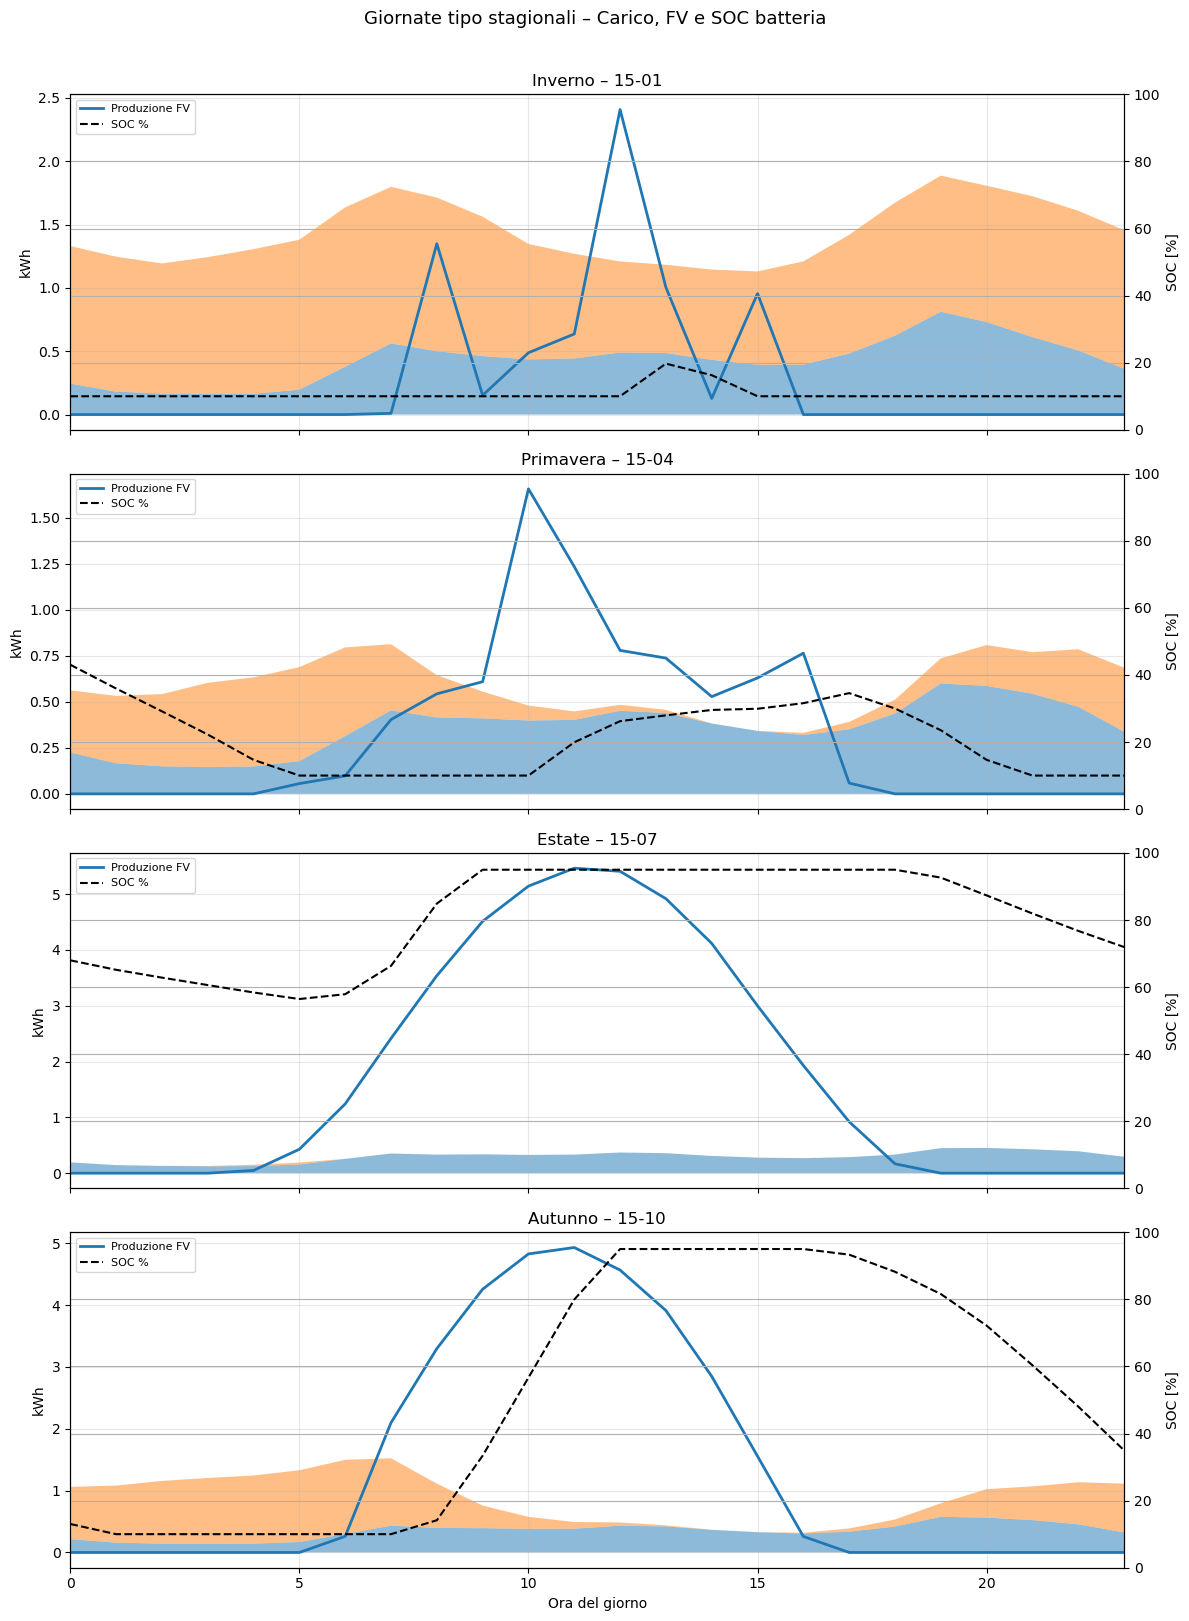

In [9]:
intestazione("📈 STEP 7 – Grafici stagionali", colore="#2471a3")

btn7 = widgets.Button(description="📊 Mostra grafici stagionali", button_style="info", layout=widgets.Layout(width="260px", margin="10px 0"))
out7 = widgets.Output()

def mostra_grafici_stagionali(_):
    with out7:
        clear_output()
        if "risultati" not in stato:
            display(HTML('<div style="background:#fadbd8;color:#922b21;padding:8px;border-radius:4px">⛔ Esegui prima il calcolo (STEP 6).</div>'))
            return

        df = stato["risultati"].get("df")
        if df is None or len(df) == 0:
            display(HTML('<div style="background:#fadbd8;color:#922b21;padding:8px;border-radius:4px">⛔ Dati orari non disponibili. Riesegui lo STEP 6.</div>'))
            return

        C_bat = stato.get("taglia_BESS", 0)
        if C_bat <= 0:
            display(HTML('<div style="background:#fef9e7;color:#b7770d;padding:8px;border-radius:4px">⚠️ Batterie assenti o taglia nulla: il SOC non può essere rappresentato correttamente.</div>'))
            C_bat = 1.0

        def assegna_stagione(m):
            if m in [12,1,2]: return "Inverno"
            elif m in [3,4,5]: return "Primavera"
            elif m in [6,7,8]: return "Estate"
            else: return "Autunno"

        df_plot = df.copy()
        df_plot["stagione"]    = df_plot["mese"].apply(assegna_stagione)
        df_plot["SOC_pct"]     = 100*df_plot["SOC_kWh"]/C_bat
        df_plot["giorno_mese"] = df_plot["timestamp"].dt.strftime("%d-%m")
        df_plot["ora"]         = df_plot["timestamp"].dt.hour
        giorni_centrali = {"Inverno":"15-01","Primavera":"15-04","Estate":"15-07","Autunno":"15-10"}

        fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
        for ax, stagione in zip(axes, ["Inverno","Primavera","Estate","Autunno"]):
            d = df_plot[df_plot["giorno_mese"]==giorni_centrali[stagione]].sort_values("ora")
            if d.empty:
                ax.set_title(f"{stagione} – dati non disponibili")
                ax.grid(True, alpha=0.3)
                continue
            ore=d["ora"].values; base=d["E_base_h_kWh"].values; hp=d["E_HP_h_kWh"].values
            pv=d["E_PV_h_kWh"].values; soc=d["SOC_pct"].values
            ax.fill_between(ore,0,base,alpha=0.5,label="Carico base")
            ax.fill_between(ore,base,base+hp,alpha=0.5,label="Carico PdC")
            ax.plot(ore,pv,lw=2,label="Produzione FV")
            ax.set_title(f"{stagione} – {giorni_centrali[stagione]}")
            ax.set_ylabel("kWh"); ax.set_xlim(0,23); ax.grid(True,alpha=0.3)
            ax2=ax.twinx()
            ax2.plot(ore,soc,"--k",lw=1.5,label="SOC %")
            ax2.set_ylabel("SOC [%]"); ax2.set_ylim(0,100)
            lines=ax.get_lines()+ax2.get_lines()
            labels=[l.get_label() for l in lines]
            ax.legend(lines, labels, loc="upper left", fontsize=8)
        axes[-1].set_xlabel("Ora del giorno")
        plt.suptitle("Giornate tipo stagionali – Carico, FV e SOC batterie", fontsize=13, y=1.01)
        plt.tight_layout()
        plt.show()

btn7.on_click(mostra_grafici_stagionali)
display(btn7, out7)
